# Piloto 2026 — verificación de carga y calidad de datos

## tl;dr

Este notebook verifica la integración reproducible de nueve fermentaciones piloto. La carga corregida conserva 39 muestras de vino para GC —seis baselines iniciales y 33 muestras emparejadas con 33 MIX—, trata NQ y bajo-LOQ como censura izquierda, representa cada MIX como una acumulación por intervalo y aplica ×1.000 sólo a los condensados. Los tres perfiles de CO₂ del Lote 1 se muestran para control visual, pero quedan fuera de la calibración. Ocho artefactos de etanol `−0,3 % v/v` fueron corregidos a cero conservando el valor original.

**Estado esperado:** carga reproducible y apta para revisión del responsable experimental; calibración todavía condicional a esa revisión y a documentar la referencia normal de MassView.


## Contexto y métodos

### Supuestos confirmados

- Ventana de proceso: primera a última muestra primaria.
- Temperatura ejecutada: `Sonda1`; el setpoint es la orden del controlador.
- Protocolo C: 16→18→21 °C; si el vino se secó antes, el tramo no ejecutado se excluye.
- MassView: Ln/min, sin segunda normalización.
- Ceros de CO₂: válidos al inicio/final e inválidos entre la primera y última señal positiva.
- Lote 3: misma operación relativa que Lote 1, desplazada a su fecha de inicio.
- MIX: concentración del vial diluido ×1.000 y masa acumulada `C_MIX × (V_A + V_B)`.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "fermentation_model" / "pilot_2026").exists():
            return candidate
    raise FileNotFoundError("No se encontró la raíz del repositorio pyomo-doe")

REPO = find_repo_root(Path.cwd().resolve())
RESULTS_RELATIVE = Path("fermentation_model/pilot_2026/results/data_integration_2026")
RESULTS = REPO / RESULTS_RELATIVE
print("Repositorio: raíz detectada")
print(f"Resultados:  {RESULTS_RELATIVE.as_posix()}")


Repositorio: raíz detectada
Resultados:  fermentation_model/pilot_2026/results/data_integration_2026


## Datos


In [2]:
qc = json.loads((RESULTS / "qc_summary.json").read_text(encoding="utf-8"))
windows = pd.read_csv(RESULTS / "process_windows.csv", parse_dates=["sampling_start", "sampling_end", "active_end"])
primary = pd.read_csv(RESULTS / "primary_results_qc.csv", parse_dates=["timestamp", "sampling_start", "active_end"])
temperature = pd.read_csv(RESULTS / "temperature_controller_qc.csv", parse_dates=["timestamp"])
temperature_summary = pd.read_csv(RESULTS / "temperature_summary.csv")
co2 = pd.read_csv(RESULTS / "co2_minute_qc.csv", parse_dates=["minute"], low_memory=False)
co2_summary = pd.read_csv(RESULTS / "co2_run_qc_summary.csv")
events = pd.read_csv(RESULTS / "operational_events_qc.csv", parse_dates=["timestamp", "sampling_start", "sampling_end", "active_end"])
gc = pd.read_csv(RESULTS / "gc_results_long_qc.csv", parse_dates=["sample_timestamp"])
gc_pairs = pd.read_csv(RESULTS / "gc_mix_wine_pairs_qc.csv", parse_dates=["timestamp", "capture_interval_start", "capture_interval_end"])
gc_pairs_long = pd.read_csv(RESULTS / "gc_mix_wine_pairs_long_qc.csv", parse_dates=["timestamp", "capture_interval_start", "capture_interval_end"])

tables = {
    "process_windows": windows,
    "primary_results": primary,
    "temperature": temperature,
    "co2_minute": co2,
    "operational_events": events,
    "gc_results_long": gc,
    "gc_pairs": gc_pairs,
    "gc_pairs_long": gc_pairs_long,
}
print(pd.DataFrame({"rows": {name: len(table) for name, table in tables.items()},
                    "columns": {name: len(table.columns) for name, table in tables.items()}}).to_string())


                      rows  columns
process_windows          9       14
primary_results        132       40
temperature          15614       13
co2_minute          102684       17
operational_events      45       33
gc_results_long        432       25
gc_pairs                33       16
gc_pairs_long          198       30


In [3]:
expected_checks = pd.DataFrame(qc["expected_value_checks"]).T
print("Controles de ingestión reproducibles")
print(expected_checks.to_string())
assert expected_checks["pass"].all()
assert len(windows) == 9 and windows["experiment_id"].nunique() == 9
assert qc["gc"]["gc_mix_wine_pair_coverage"] == 1.0
assert qc["primary_results"]["ethanol_negative_formula_artifacts_set_to_zero"] == 8
print("\nPASS: conteos históricos y reglas nuevas reconciliados.")


Controles de ingestión reproducibles
                                                        expected observed  pass
fermentations                                                  9        9  True
massview_rows                                            5239087  5239087  True
flow_rows_in_sampling_windows                            4752937  4752937  True
same_second_groups_before_sentinel_filter                4272044  4272044  True
same_second_repetitions_absorbed_before_sentinel_filter   480893   480893  True
raw_2_621_observations                                      3970     3970  True
modbus_events_26136                                            1        1  True
out_of_order_flow_timestamps                                   0        0  True
maximum_flow_gap_seconds                                      10     10.0  True

PASS: conteos históricos y reglas nuevas reconciliados.


In [4]:
window_view = windows[["experiment_id", "lot", "reactor", "protocol", "sampling_start", "active_end", "sampling_end", "primary_samples"]].copy()
window_view["duration_h"] = (window_view["sampling_end"] - window_view["sampling_start"]).dt.total_seconds() / 3600
window_view["active_h"] = (window_view["active_end"] - window_view["sampling_start"]).dt.total_seconds() / 3600
print(window_view.round(2).to_string(index=False))


 experiment_id    lot reactor protocol      sampling_start          active_end        sampling_end  primary_samples  duration_h  active_h
         26134 Lote 1   TK-31        A 2026-03-25 16:00:00 2026-04-02 08:00:00 2026-04-02 08:00:00               15       184.0    184.00
         26135 Lote 1   TK-32        A 2026-03-25 16:00:00 2026-04-02 08:00:00 2026-04-02 08:00:00               15       184.0    184.00
         26136 Lote 1   TK-33        B 2026-03-25 16:00:00 2026-04-02 08:00:00 2026-04-02 08:00:00               14       184.0    184.00
         26157 Lote 2   TK-31        A 2026-04-06 13:00:00 2026-04-13 16:22:18 2026-04-14 15:00:00               16       194.0    171.37
         26158 Lote 2   TK-32        A 2026-04-06 13:00:00 2026-04-13 16:24:31 2026-04-14 15:00:00               16       194.0    171.41
         26159 Lote 2   TK-33        C 2026-04-06 13:00:00 2026-04-15 08:00:00 2026-04-15 08:00:00               15       211.0    211.00
         26210 Lote 3   TK-31     

## Resultados


### 1. Resultados primarios y corrección de etanol


Correcciones de etanol (original → procesado):
Código muestra           timestamp  ethanol_real_original_percent_vv  Cf Alcolyzer Real (% v/v)       process_phase
    26157-P-14 2026-04-13 15:00:00                              -0.3                        0.0      active_process
    26157-P-15 2026-04-14 08:00:00                              -0.3                        0.0 postprocess_cooling
    26157-P-16 2026-04-14 15:00:00                              -0.3                        0.0 postprocess_cooling
    26158-P-14 2026-04-13 15:00:00                              -0.3                        0.0      active_process
    26158-P-15 2026-04-14 08:00:00                              -0.3                        0.0 postprocess_cooling
    26158-P-16 2026-04-14 15:00:00                              -0.3                        0.0 postprocess_cooling
    26210-P-04 2026-04-19 08:00:00                              -0.3                        0.0      active_process
    26211-P-04 2026-04-19

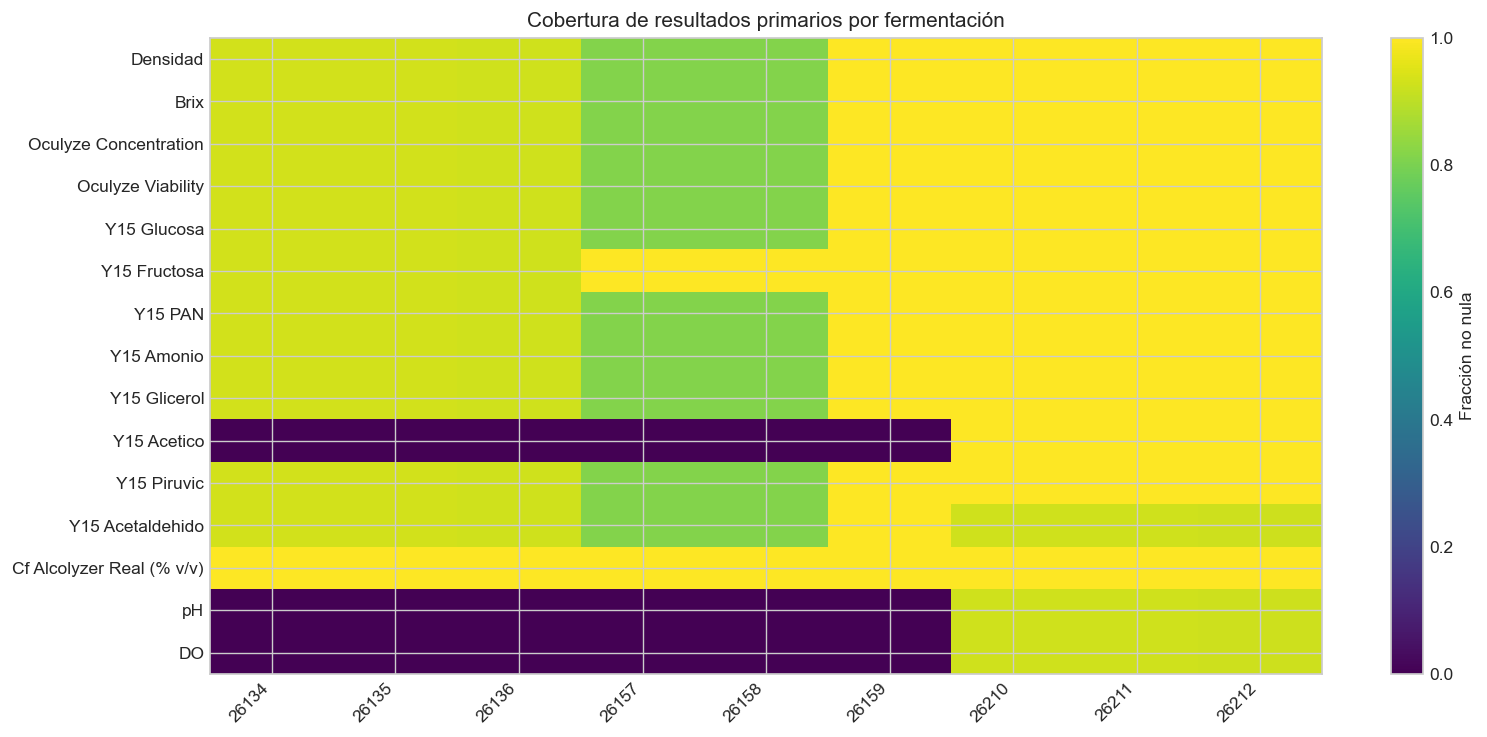

In [5]:
core_columns = [
    "Densidad", "Brix", "Oculyze Concentration", "Oculyze Viability",
    "Y15 Glucosa", "Y15 Fructosa", "Y15 PAN", "Y15 Amonio",
    "Y15 Glicerol", "Y15 Acetico", "Y15 Piruvic", "Y15 Acetaldehido",
    "Cf Alcolyzer Real (% v/v)", "pH", "DO",
]
coverage = primary.groupby("experiment_id")[core_columns].apply(lambda frame: frame.notna().mean()).T
fig, ax = plt.subplots(figsize=(13, 6))
image = ax.imshow(coverage.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="viridis")
ax.set_yticks(range(len(coverage.index)), coverage.index)
ax.set_xticks(range(len(coverage.columns)), coverage.columns, rotation=45, ha="right")
ax.set_title("Cobertura de resultados primarios por fermentación")
fig.colorbar(image, ax=ax, label="Fracción no nula")
fig.tight_layout()
plt.show()

corrected = primary[primary["ethanol_correction"].ne("none")][
    ["Código muestra", "timestamp", "ethanol_real_original_percent_vv", "Cf Alcolyzer Real (% v/v)", "process_phase"]
]
print("Correcciones de etanol (original → procesado):")
print(corrected.to_string(index=False))


### 2. Temperatura medida frente a setpoint


 experiment_id  temperature_rows_in_sampling_window  mean_absolute_setpoint_error_c  p95_absolute_setpoint_error_c          active_end_source
         26134                                 1148                           0.621                            1.5        last_primary_sample
         26135                                 1098                           0.591                            1.5        last_primary_sample
         26136                                  858                           0.519                            0.9        last_primary_sample
         26157                                 1646                           0.782                            1.8 IMPOSTA_CTA_mode2_9_to_11C
         26158                                 1666                           0.802                            1.8 IMPOSTA_CTA_mode2_9_to_11C
         26159                                  956                           0.369                            0.8        last_primary_sample
      

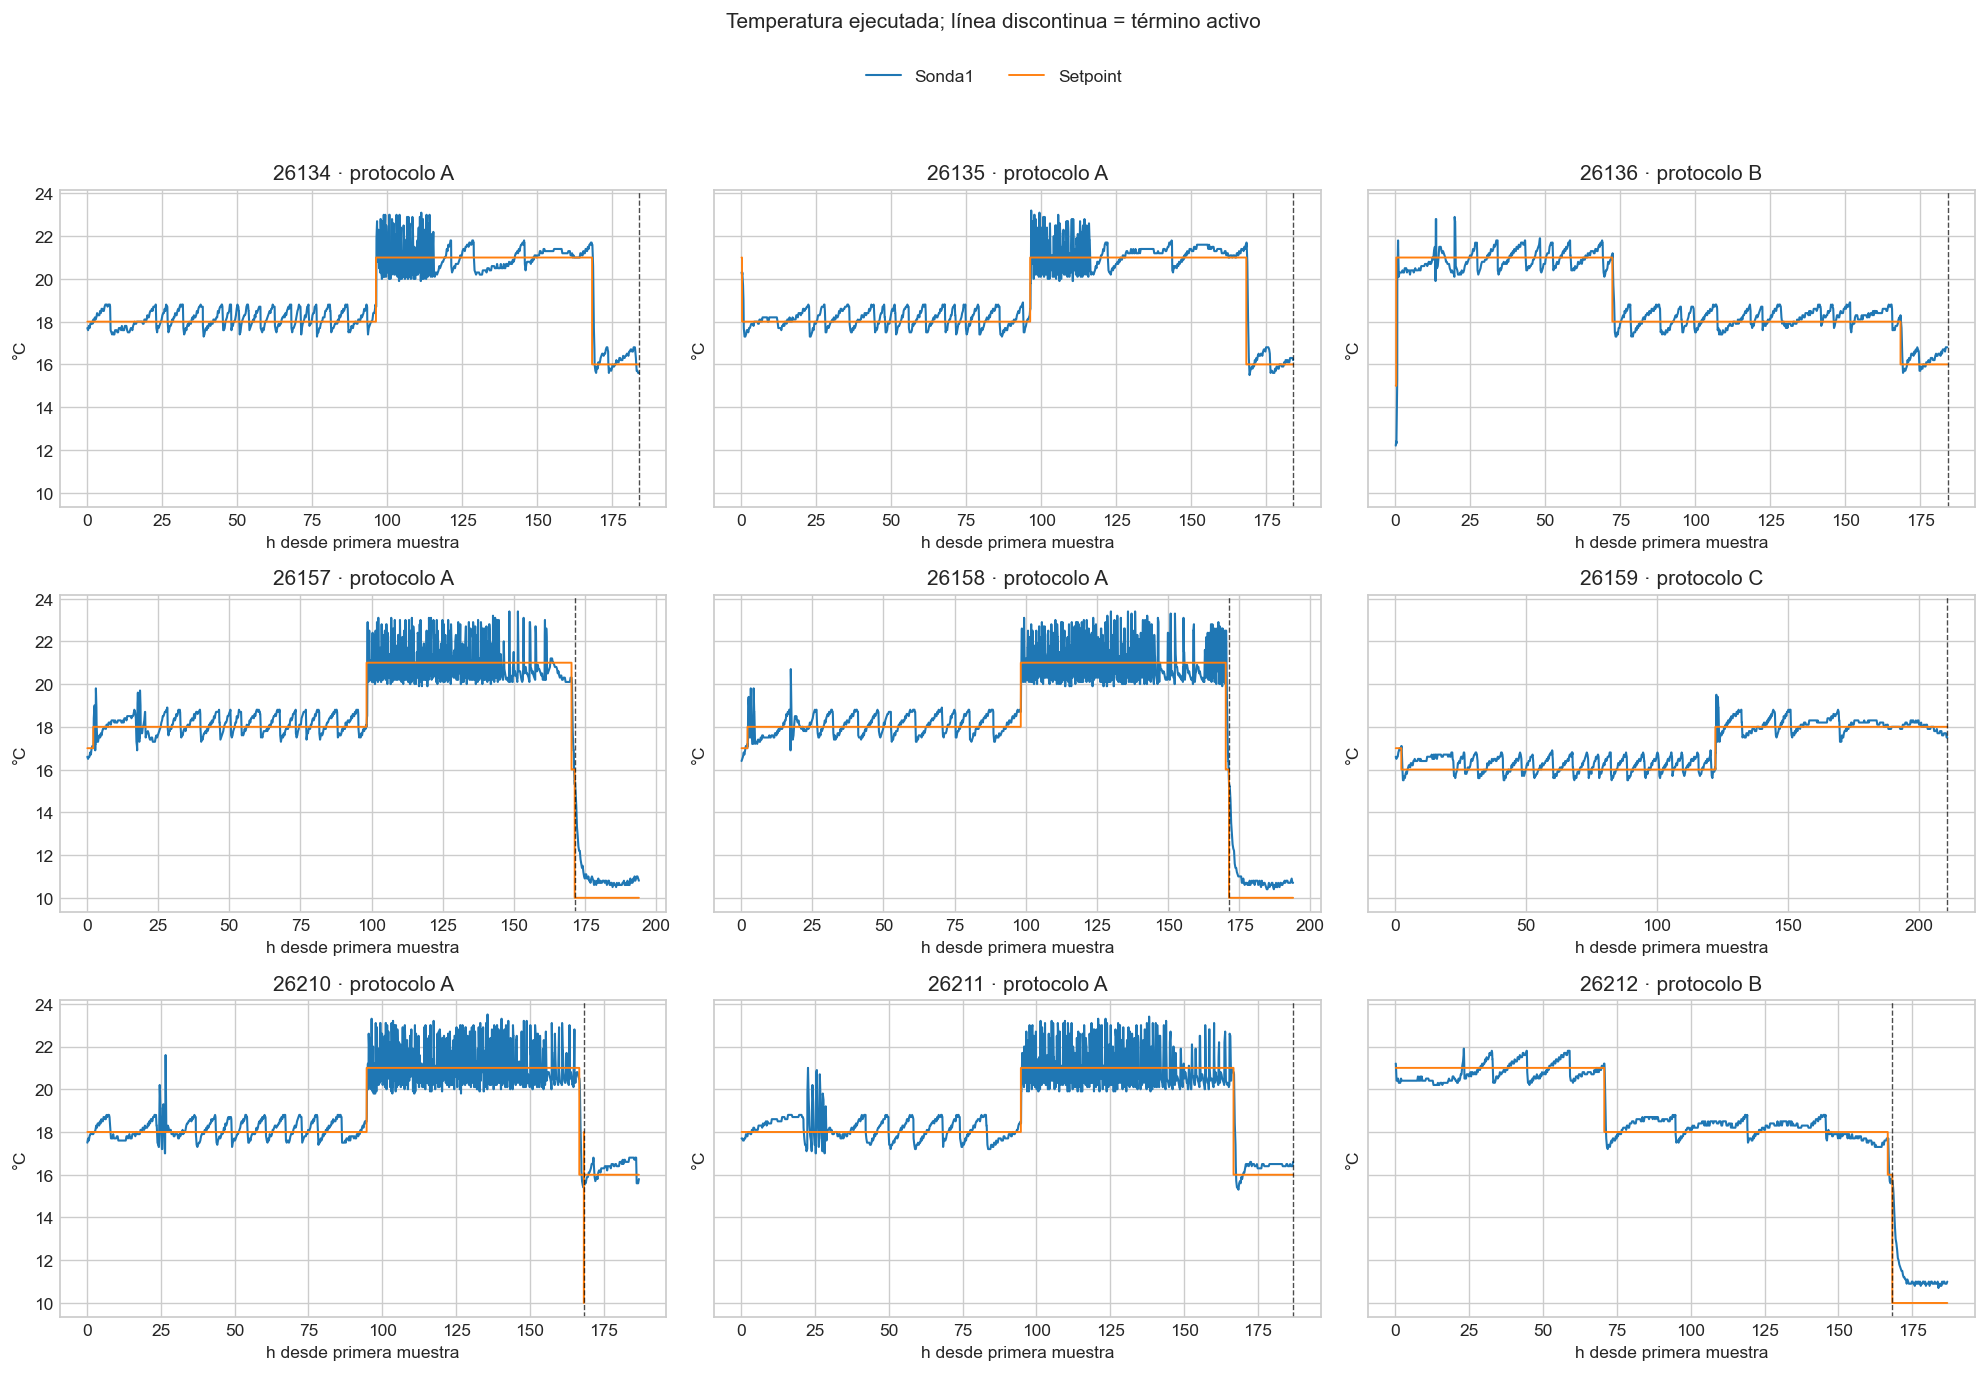

In [6]:
window_lookup = windows.set_index("experiment_id")
runs = windows["experiment_id"].astype(str).tolist()
fig, axes = plt.subplots(3, 3, figsize=(16, 11), sharey=True)
for ax, run in zip(axes.flat, runs):
    frame = temperature[(temperature["experiment_id"].astype(str).eq(run)) & temperature["inside_sampling_window"]].copy()
    t0 = window_lookup.loc[int(run) if windows["experiment_id"].dtype.kind in "iu" else run, "sampling_start"]
    hours = (frame["timestamp"] - t0).dt.total_seconds() / 3600
    ax.plot(hours, frame["sensor_1_c"], lw=1.2, label="Sonda1")
    ax.step(hours, frame["setpoint_c"], where="post", lw=1.1, label="Setpoint")
    active_h = (pd.Timestamp(window_lookup.loc[int(run) if windows["experiment_id"].dtype.kind in "iu" else run, "active_end"]) - t0).total_seconds() / 3600
    ax.axvline(active_h, color="black", ls="--", lw=0.8, alpha=0.7)
    ax.set_title(f"{run} · protocolo {window_lookup.loc[int(run) if windows['experiment_id'].dtype.kind in 'iu' else run, 'protocol']}")
    ax.set_xlabel("h desde primera muestra")
    ax.set_ylabel("°C")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.965), ncol=2)
fig.suptitle("Temperatura ejecutada; línea discontinua = término activo", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.925))
plt.show()
print(temperature_summary[["experiment_id", "temperature_rows_in_sampling_window", "mean_absolute_setpoint_error_c", "p95_absolute_setpoint_error_c", "active_end_source"]].round(3).to_string(index=False))


### 3. CO₂: calidad visual y alcance de calibración


 experiment_id  co2_model_include  invalid_intermediate_zero_seconds  valid_observed_edge_zero_seconds  postprocess_observed_seconds       co2_model_exclusion_reason
         26134              False                              88805                             15079                             0 owner_confirmed_poor_signal_lot1
         26135              False                              61292                             15638                             0 owner_confirmed_poor_signal_lot1
         26136              False                             143794                             14865                             0 owner_confirmed_poor_signal_lot1
         26157               True                              32966                              1568                         41347                              NaN
         26158               True                              44172                              1727                         42394                              NaN
    

C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\pyomo-doe\fermentation_model\pilot_2026\notebooks\pilot_2026_data_loading_qc.ipynb:15: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  "execution_count": 1,
C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\pyomo-doe\fermentation_model\pilot_2026\notebooks\build_and_execute_data_loading_qc_notebook.py:360: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  figure.savefig(buffer, format="png", dpi=125, bbox_inches="tight")


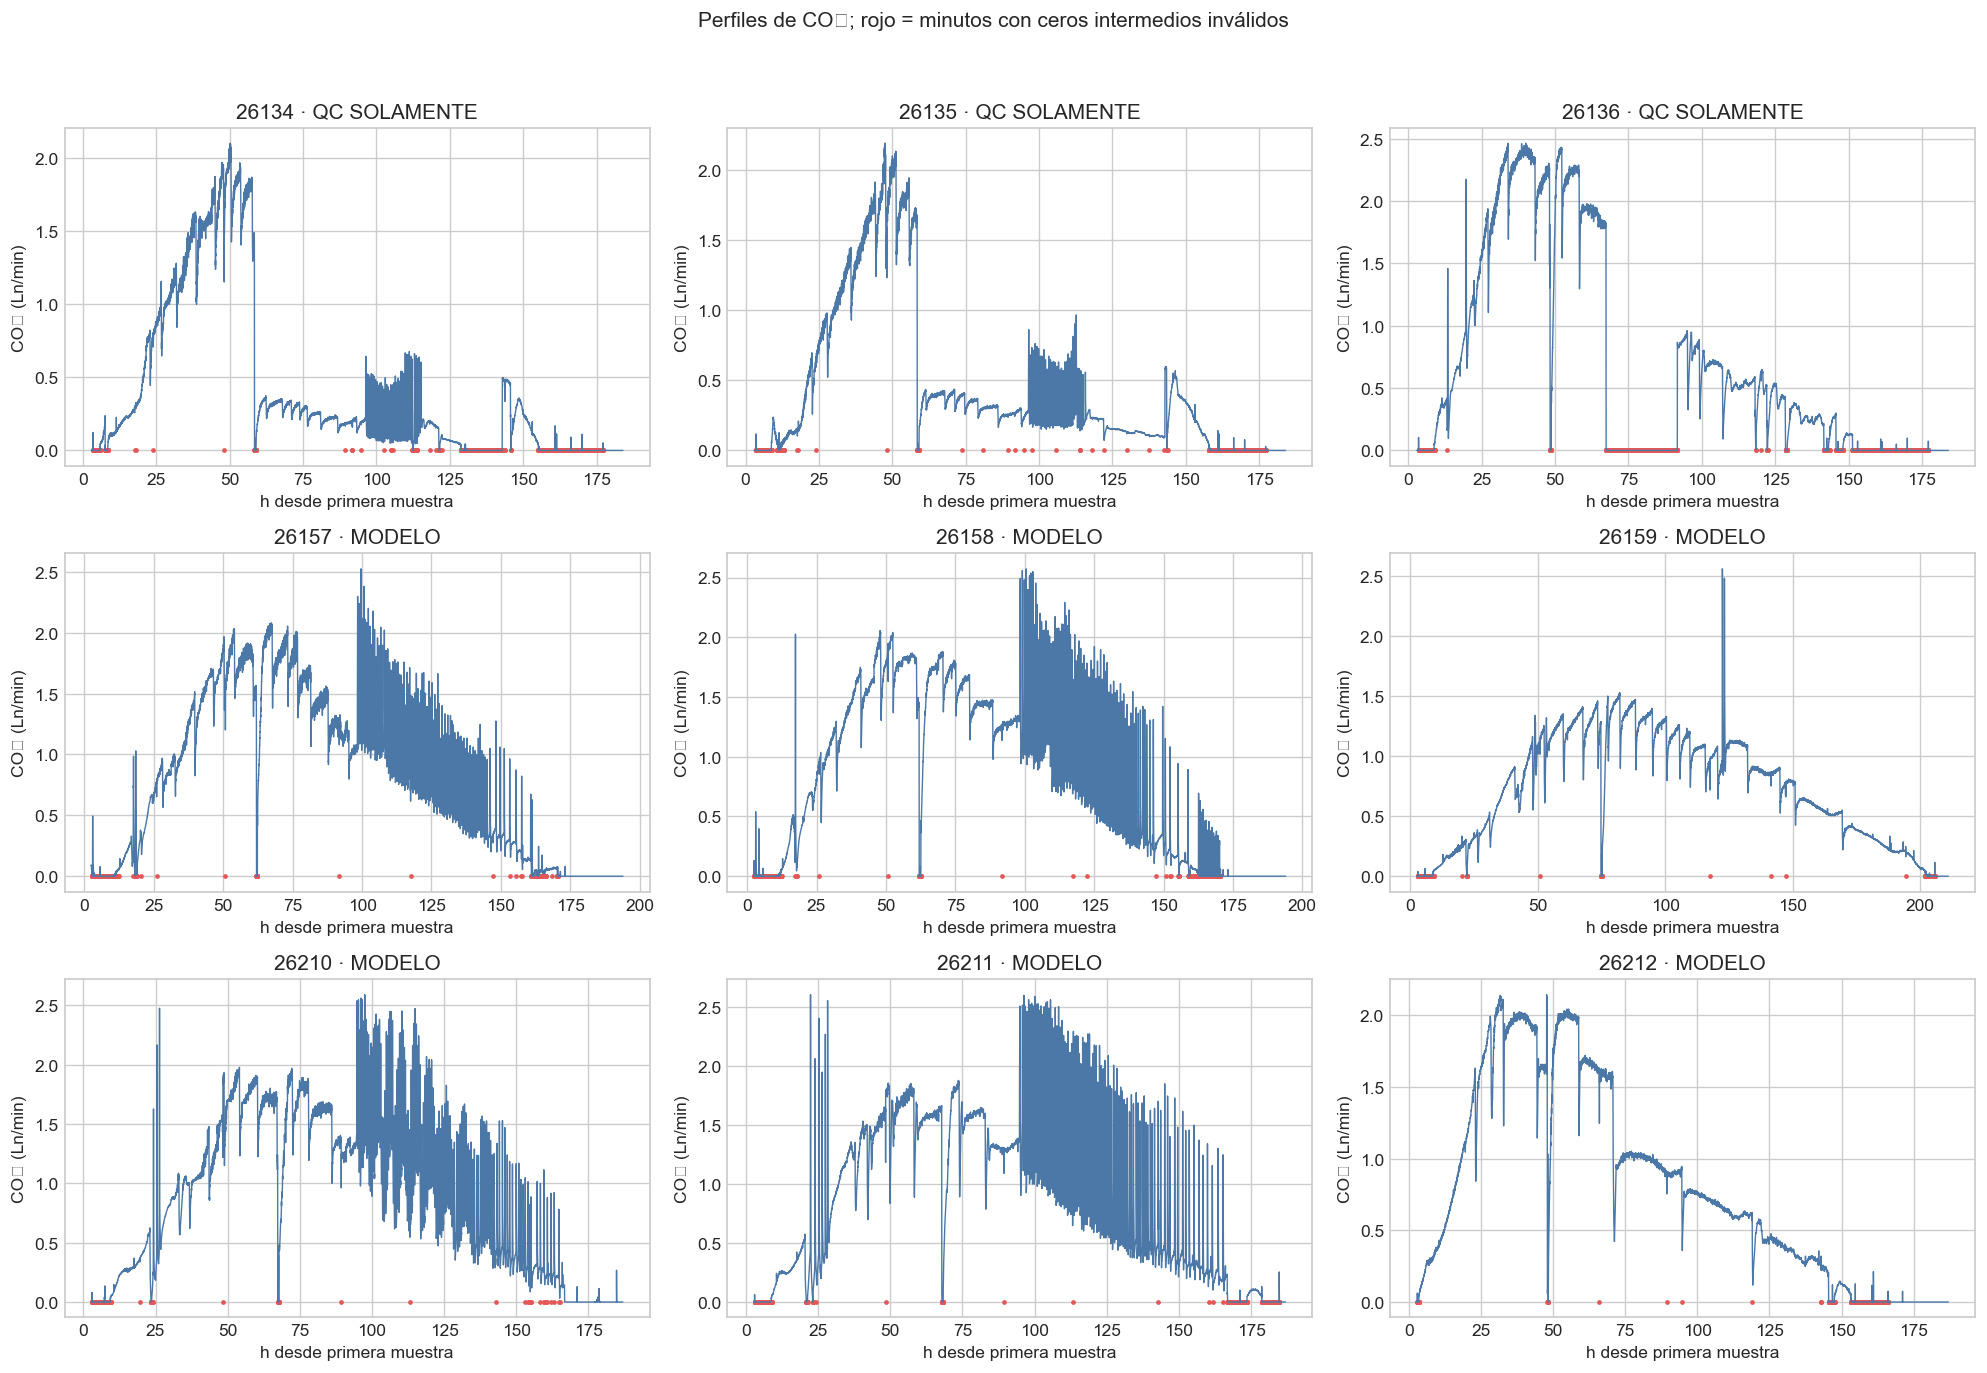

In [7]:
print(co2_summary[["experiment_id", "co2_model_include", "invalid_intermediate_zero_seconds", "valid_observed_edge_zero_seconds", "postprocess_observed_seconds", "co2_model_exclusion_reason"]].to_string(index=False))
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for ax, run in zip(axes.flat, runs):
    frame = co2[co2["experiment_id"].astype(str).eq(run)].copy()
    t0 = pd.Timestamp(window_lookup.loc[int(run) if windows["experiment_id"].dtype.kind in "iu" else run, "sampling_start"])
    hours = (frame["minute"] - t0).dt.total_seconds() / 3600
    ax.plot(hours, frame["mean_flow_ln_min_observed"], lw=0.8, color="#4c78a8")
    invalid = frame["invalid_intermediate_zero"].fillna(0).gt(0)
    ax.scatter(hours[invalid], np.zeros(invalid.sum()), s=3, color="#e45756")
    included = bool(frame["co2_model_include"].iloc[0])
    ax.set_title(f"{run} · {'MODELO' if included else 'QC SOLAMENTE'}")
    ax.set_xlabel("h desde primera muestra")
    ax.set_ylabel("CO₂ (Ln/min)")
fig.suptitle("Perfiles de CO₂; rojo = minutos con ceros intermedios inválidos", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


### 4. Eventos operacionales


event_origin   master_workbook  reconstructed_from_lot1_relative_schedule
experiment_id                                                            
26134                        5                                          0
26135                        5                                          0
26136                        5                                          0
26157                        5                                          0
26158                        5                                          0
26159                        5                                          0
26210                        0                                          5
26211                        0                                          5
26212                        0                                          5

Eventos excluidos del proceso activo:
 experiment_id           timestamp          Tipo evento Producto/Nutriente    event_origin
         26159 2026-04-15 16:00:00 Cambio temperatura 2 

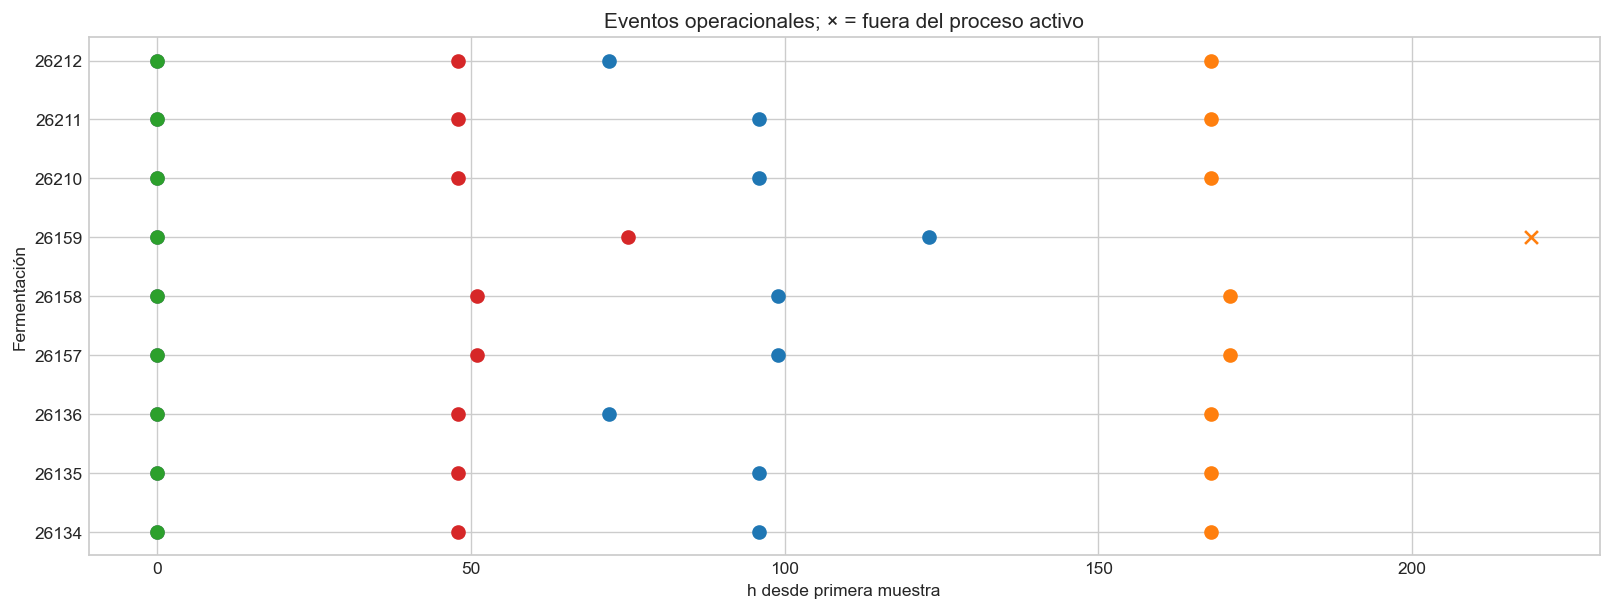

In [8]:
event_counts = events.groupby(["experiment_id", "event_origin"]).size().unstack(fill_value=0)
print(event_counts.to_string())
print("\nEventos excluidos del proceso activo:")
print(events[~events["calibration_include"]][["experiment_id", "timestamp", "Tipo evento", "Producto/Nutriente", "event_origin"]].to_string(index=False))
print("\nNutrición derivada de 116 g orgánico + 46 g FDA por pulso:")
print(events[events["dose_parse_status"].eq("parsed_springferm_organic_plus_fda")][["experiment_id", "relative_time_h", "organic_product_g", "dap_product_g", "yan_added_mg_l", "event_timestamp_status"]].round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 5))
event_types = {name: idx for idx, name in enumerate(sorted(events["Tipo evento"].dropna().unique()))}
for run_index, run in enumerate(runs):
    frame = events[events["experiment_id"].astype(str).eq(run)]
    for _, row in frame.iterrows():
        color = plt.cm.tab10(event_types[row["Tipo evento"]] % 10)
        ax.scatter(row["relative_time_h"], run_index, color=color, s=55, marker="o" if row["calibration_include"] else "x")
ax.set_yticks(range(len(runs)), runs)
ax.set_xlabel("h desde primera muestra")
ax.set_ylabel("Fermentación")
ax.set_title("Eventos operacionales; × = fuera del proceso activo")
fig.tight_layout()
plt.show()


### 5. GC: baseline, emparejamiento, censura y masa capturada


                samples  analyte_results  numeric  left_censored
sample_type                                                     
condensate_mix       33              198      111            122
wine_mef             39              234      221             14

Pares MIX–vino: 33; cobertura: 100.0%
Baselines de vino sin MIX: 6
 experiment_id       mix_id paired_wine_sample_id           timestamp  capture_interval_h  total_condensate_ml
         26157 26157-MIX-01            26157-P-05 2026-04-08 15:00:00                50.0                 12.1
         26157 26157-MIX-02            26157-P-08 2026-04-10 08:00:00                41.0                 35.0
         26157 26157-MIX-03            26157-P-10 2026-04-11 08:00:00                24.0                 40.0
         26157 26157-MIX-04            26157-P-12 2026-04-12 15:00:00                31.0                 38.0
         26157 26157-MIX-05            26157-P-13 2026-04-13 08:00:00                17.0                  9.0
      

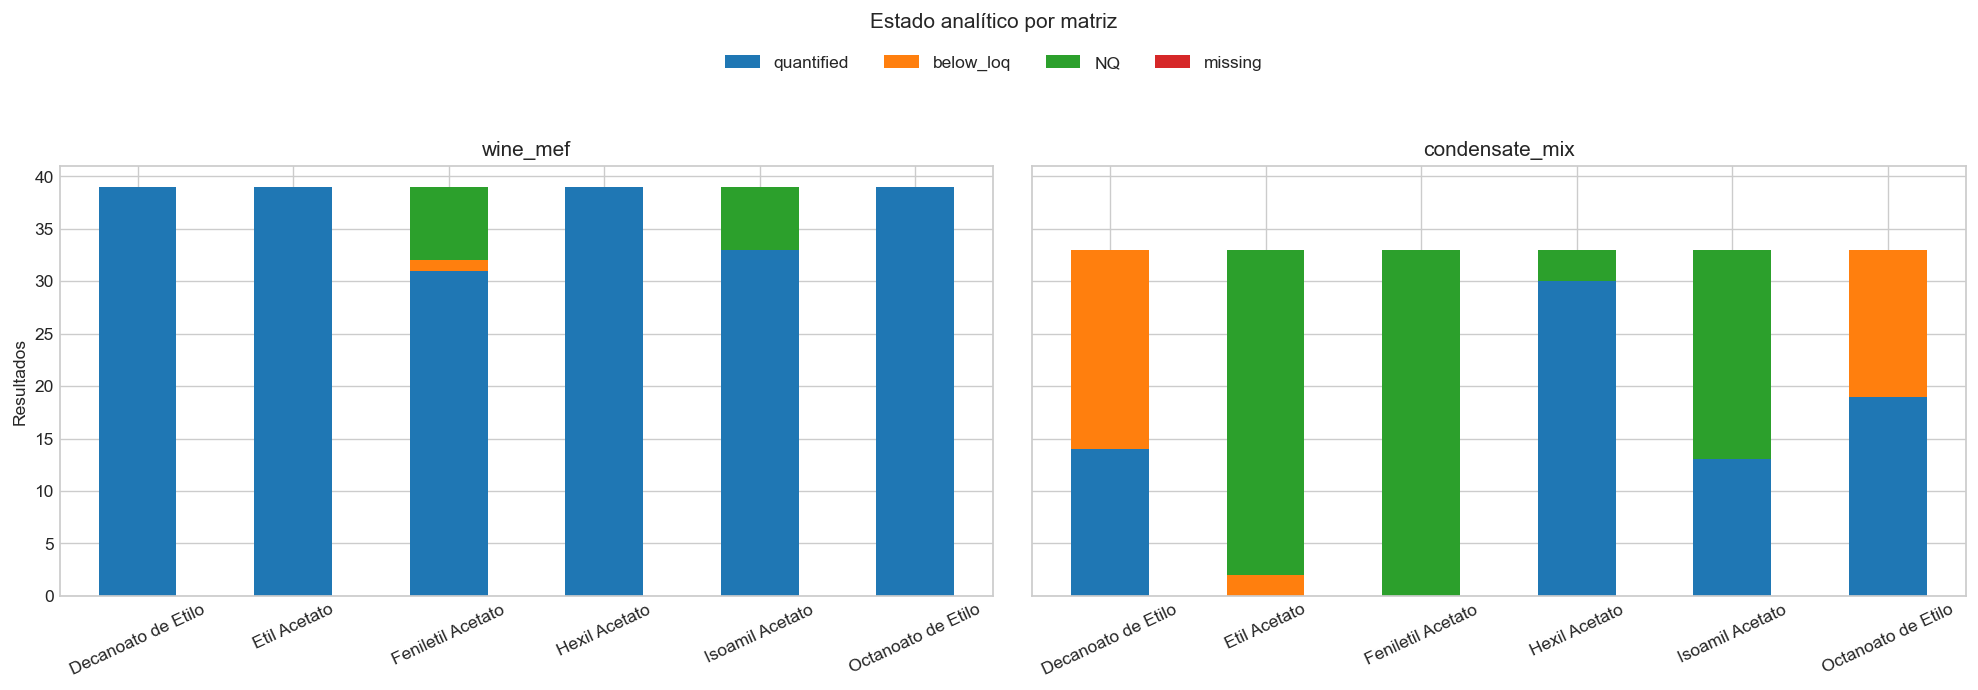

In [9]:
gc_summary = pd.DataFrame({
    "samples": gc.groupby("sample_type")["sample_id"].nunique(),
    "analyte_results": gc.groupby("sample_type").size(),
    "numeric": gc.groupby("sample_type")["vial_concentration_ug_l"].apply(lambda x: x.notna().sum()),
    "left_censored": gc.groupby("sample_type")["model_observation_type"].apply(lambda x: x.eq("left_censored").sum()),
})
print(gc_summary.to_string())
print(f"\nPares MIX–vino: {len(gc_pairs)}; cobertura: {gc_pairs['wine_pair_available'].mean():.1%}")
print(f"Baselines de vino sin MIX: {qc['gc']['gc_initial_wine_samples_without_mix']}")
print(gc_pairs[["experiment_id", "mix_id", "paired_wine_sample_id", "timestamp", "capture_interval_h", "total_condensate_ml"]].head(12).round(2).to_string(index=False))

status = gc.groupby(["sample_type", "analyte", "result_status"]).size().rename("n").reset_index()
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
for ax, sample_type in zip(axes, ["wine_mef", "condensate_mix"]):
    pivot = status[status["sample_type"].eq(sample_type)].pivot(index="analyte", columns="result_status", values="n").fillna(0)
    pivot = pivot.reindex(columns=["quantified", "below_loq", "NQ", "missing"], fill_value=0)
    pivot.plot.bar(stacked=True, ax=ax, legend=False)
    ax.set_title(sample_type)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
axes[0].set_ylabel("Resultados")
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.955), ncol=4)
fig.suptitle("Estado analítico por matriz", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.89))
plt.show()


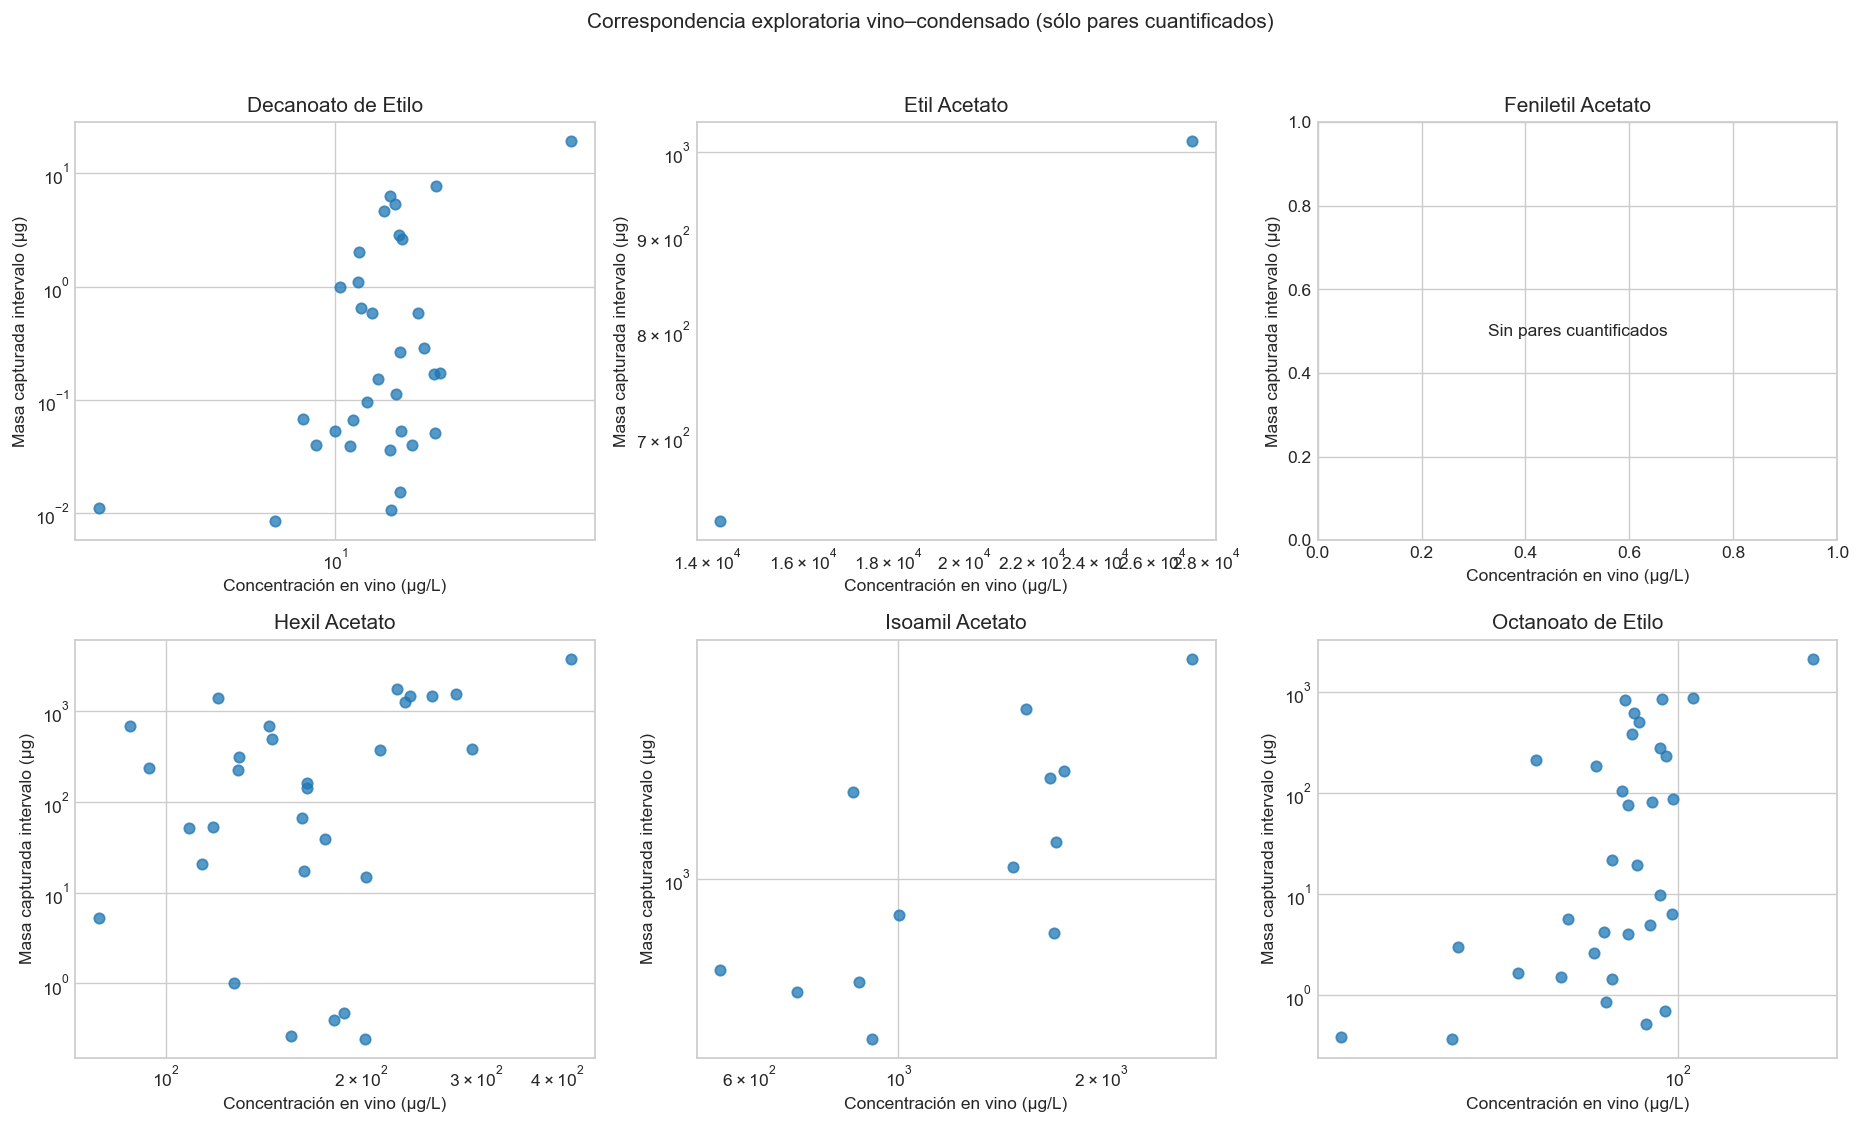

In [10]:
analytes = sorted(gc_pairs_long["analyte"].unique())
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, analyte in zip(axes.flat, analytes):
    frame = gc_pairs_long[
        gc_pairs_long["analyte"].eq(analyte)
        & gc_pairs_long["wine_concentration_ug_l"].notna()
        & gc_pairs_long["captured_mass_ug"].notna()
        & gc_pairs_long["wine_concentration_ug_l"].gt(0)
        & gc_pairs_long["captured_mass_ug"].gt(0)
    ]
    if len(frame):
        ax.scatter(frame["wine_concentration_ug_l"], frame["captured_mass_ug"], alpha=0.75)
        ax.set_xscale("log")
        ax.set_yscale("log")
    else:
        ax.text(0.5, 0.5, "Sin pares cuantificados", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(analyte)
    ax.set_xlabel("Concentración en vino (µg/L)")
    ax.set_ylabel("Masa capturada intervalo (µg)")
fig.suptitle("Correspondencia exploratoria vino–condensado (sólo pares cuantificados)", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


### 6. Controles finales automáticos


In [11]:
checks = {
    "9 fermentaciones": len(windows) == 9,
    "todas las fechas MIX Lote 2 están en abril": gc_pairs.loc[gc_pairs["experiment_id"].isin([26157, 26158, 26159]), "timestamp"].dt.month.eq(4).all(),
    "39 vinos GC": gc.loc[gc["sample_type"].eq("wine_mef"), "sample_id"].nunique() == 39,
    "33 MIX GC": gc.loc[gc["sample_type"].eq("condensate_mix"), "sample_id"].nunique() == 33,
    "33 pares MIX–vino": len(gc_pairs) == 33 and gc_pairs["wine_pair_available"].all(),
    "6 baselines sin MIX": qc["gc"]["gc_initial_wine_samples_without_mix"] == 6,
    "8 etanoles corregidos a cero": len(corrected) == 8 and corrected["Cf Alcolyzer Real (% v/v)"].eq(0).all(),
    "15 eventos reconstruidos Lote 3": events["event_origin"].eq("reconstructed_from_lot1_relative_schedule").sum() == 15,
    "CO2 Lote 1 fuera del modelo": not co2_summary.loc[co2_summary["experiment_id"].isin([26134, 26135, 26136]), "co2_model_include"].any(),
    "NQ/bajo LOQ permanecen censurados": gc.loc[gc["result_status"].isin(["NQ", "below_loq"]), "model_observation_type"].eq("left_censored").all(),
}
check_table = pd.Series(checks, name="PASS").to_frame()
print(check_table.to_string())
assert check_table["PASS"].all(), check_table[~check_table["PASS"]]
print("\nVEREDICTO DEL NOTEBOOK: PASS para carga y reglas del responsable experimental.")


                                            PASS
9 fermentaciones                            True
todas las fechas MIX Lote 2 están en abril  True
39 vinos GC                                 True
33 MIX GC                                   True
33 pares MIX–vino                           True
6 baselines sin MIX                         True
8 etanoles corregidos a cero                True
15 eventos reconstruidos Lote 3             True
CO2 Lote 1 fuera del modelo                 True
NQ/bajo LOQ permanecen censurados           True

VEREDICTO DEL NOTEBOOK: PASS para carga y reglas del responsable experimental.


## Takeaways

- La carga es internamente coherente y reproduce todos los conteos auditados.
- Las fechas GC del Lote 2 quedan en abril y los 33 MIX tienen correspondencia 1:1 con vino; las seis muestras iniciales de vino permanecen como baseline.
- Las observaciones censuradas siguen disponibles para una likelihood censurada y no fueron convertidas a cero.
- El CO₂ de Lote 1 puede inspeccionarse, pero no se entregará como observación de calibración.
- La temperatura de calibración será `Sonda1`; los perfiles se diseñarán como setpoints y deberán pasar por un modelo del controlador.
- Los eventos del Lote 3 están reconstruidos de forma trazable desde Lote 1. El segundo pulso conserva la advertencia de que su hora es un proxy ligado a densidad.
- La dosis `116 + 46 g` equivale a 90,435 mg/L YAN por pulso a 230 L con los factores confirmados; falta reconciliarla con el nominal de 80 mg/L antes de calibrar nutrición.
- Siguiente gate: revisión visual del responsable y construcción del adaptador de estas tablas al modelo jerárquico previo al MBDoE adaptativo.
